# AIRPATH-AI Milestone 3A — spatial PM2.5 estimation

This executable notebook reproduces the development-only spatial analysis implemented in `src/spatial_estimation.py`.

Protocol:

- coordinates come from HealthyAir/Data in Brief Table 1 (doi:10.1016/j.dib.2022.108774);
- leave one complete station out at a time;
- use only the existing train + validation period;
- compare nearest station, IDW p=1, and IDW p=2;
- keep the forecasting test period out of spatial comparison;
- treat reliability quantities as geometry proxies, not prediction intervals;
- do not infer minute-level support from the exact-time software interface.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_estimation import (
    STATION_BY_ID,
    estimate_deployment_pm25,
    estimate_oracle_pm25,
    generate_analysis_outputs,
)

In [2]:
outputs = generate_analysis_outputs(
    PROJECT_ROOT / "data/processed/airquality_hcmc_clean.csv",
    PROJECT_ROOT / "reports",
)

geometry = outputs["geometry"]
distances = outputs["distances"]
metrics = outputs["metrics"]
temporal = outputs["temporal"]
reliability = outputs["reliability"]

geometry[["station_id", "latitude", "longitude", "station_type", "location"]]

,station_id,latitude,longitude,station_type,location
0,1,10.869943,106.796014,Urban background: Industry + Traffic + Residen...,"Vietnam National University, Linh Trung ward, ..."
1,2,10.740971,106.617132,Traffic,"20 Nguyen Trong Tri street, An Lac ward, Binh ..."
2,3,10.816212,106.620414,Industry,"Tan Binh industrial zone, Tay Thanh ward, Tan ..."
3,4,10.815846,106.717428,Residential,"49 Thanh Da street, Ward 27, Binh Thanh distri..."
4,5,10.776366,106.687809,Traffic,"268 Nguyen Dinh Chieu street, Ward 6, District..."
5,6,10.780472,106.659458,Traffic + Residential,"MM18 Truong Son street, Ward 14, District 10, ..."


In [3]:
pooled = metrics.loc[metrics["held_out_station"].eq("ALL")]
held_out = metrics.loc[~metrics["held_out_station"].eq("ALL")]

print("Pooled LOSO development results")
display(pooled)
print("Held-out station results")
display(held_out)
print("Temporal robustness")
display(temporal)
print("Reliability proxies (not calibrated intervals)")
display(reliability)

Pooled LOSO development results


,model,held_out_station,n,unique_timestamps,mae,rmse,r2
6,nearest,ALL,25368,4228,8.703751,15.461214,0.022704
13,idw_p1,ALL,25368,4228,7.060645,12.720785,0.338444
20,idw_p2,ALL,25368,4228,7.173672,12.897832,0.319900


Held-out station results


,model,held_out_station,n,unique_timestamps,mae,rmse,r2
0,nearest,1,4228,4228,10.261527,19.686913,-2.101090
1,nearest,2,4228,4228,3.811611,6.963926,0.692820
2,nearest,3,4228,4228,8.442984,15.933897,0.402994
3,nearest,4,4228,4228,15.183988,23.504325,-0.312252
4,nearest,5,4228,4228,7.261199,9.794940,-0.335276
5,nearest,6,4228,4228,7.261199,9.794940,0.211046
7,idw_p1,1,4228,4228,6.771412,10.404047,0.133909
8,idw_p1,2,4228,4228,4.112113,6.993435,0.690211
9,idw_p1,3,4228,4228,8.505049,15.829731,0.410774
10,idw_p1,4,4228,4228,9.725776,18.989126,0.143492


Temporal robustness


,period,period_start,period_end,model,n,unique_timestamps,mae,rmse,r2
0,early,2021-02-24 16:00:00,2021-11-16 22:00:00,idw_p1,8460,1410,6.025289,13.952257,0.140482
1,early,2021-02-24 16:00:00,2021-11-16 22:00:00,idw_p2,8460,1410,5.932420,14.179872,0.112209
2,early,2021-02-24 16:00:00,2021-11-16 22:00:00,nearest,8460,1410,6.753172,17.363265,-0.331155
3,middle,2021-11-16 23:00:00,2022-01-23 05:00:00,idw_p1,8454,1409,9.157235,14.220750,0.322031
4,middle,2021-11-16 23:00:00,2022-01-23 05:00:00,idw_p2,8454,1409,9.322748,14.307152,0.313767
5,middle,2021-11-16 23:00:00,2022-01-23 05:00:00,nearest,8454,1409,11.511437,16.677482,0.067549
6,late,2022-01-23 06:00:00,2022-04-07 17:00:00,idw_p1,8454,1409,6.000145,9.409390,0.438237
7,late,2022-01-23 06:00:00,2022-04-07 17:00:00,idw_p2,8454,1409,6.266729,9.657854,0.408177
8,late,2022-01-23 06:00:00,2022-04-07 17:00:00,nearest,8454,1409,7.848030,11.725260,0.127681


Reliability proxies (not calibrated intervals)


,model,held_out_station,nearest_distance_km,second_nearest_distance_km,contributing_stations,maximum_weight,weight_concentration,effective_station_count
0,idw_p1,1,10.480571,15.745847,5,0.312070,0.218541,4.575798
1,idw_p1,2,6.377327,8.374158,5,0.310170,0.231426,4.321040
2,idw_p1,3,5.829304,8.374158,5,0.311049,0.225601,4.432600
3,idw_p1,4,5.453228,7.454146,5,0.316171,0.222705,4.490244
4,idw_p1,5,3.130395,5.453228,5,0.400253,0.261495,3.824158
5,idw_p1,6,3.130395,5.829304,5,0.381325,0.252455,3.961104
6,idw_p2,1,10.480571,15.745847,5,0.445627,0.282417,3.540859
7,idw_p2,2,6.377327,8.374158,5,0.415709,0.290422,3.443270
8,idw_p2,3,5.829304,8.374158,5,0.428860,0.284229,3.518285
9,idw_p2,4,5.453228,7.454146,5,0.448863,0.293060,3.412270


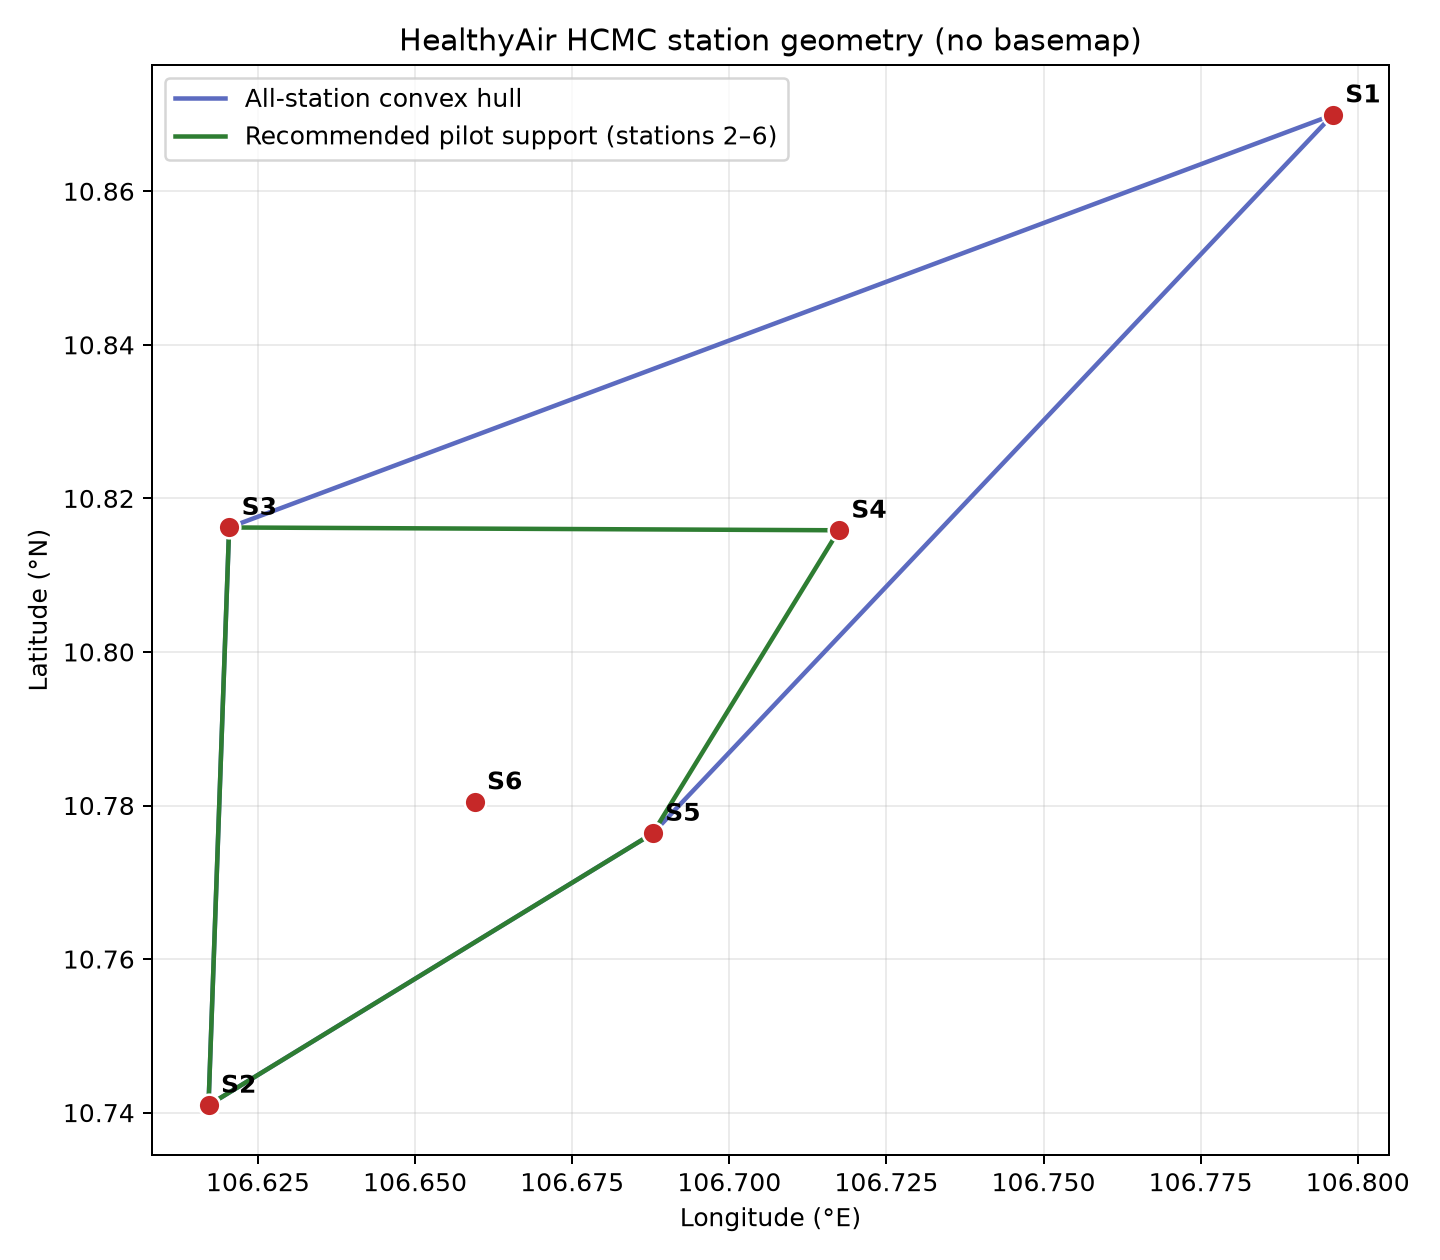

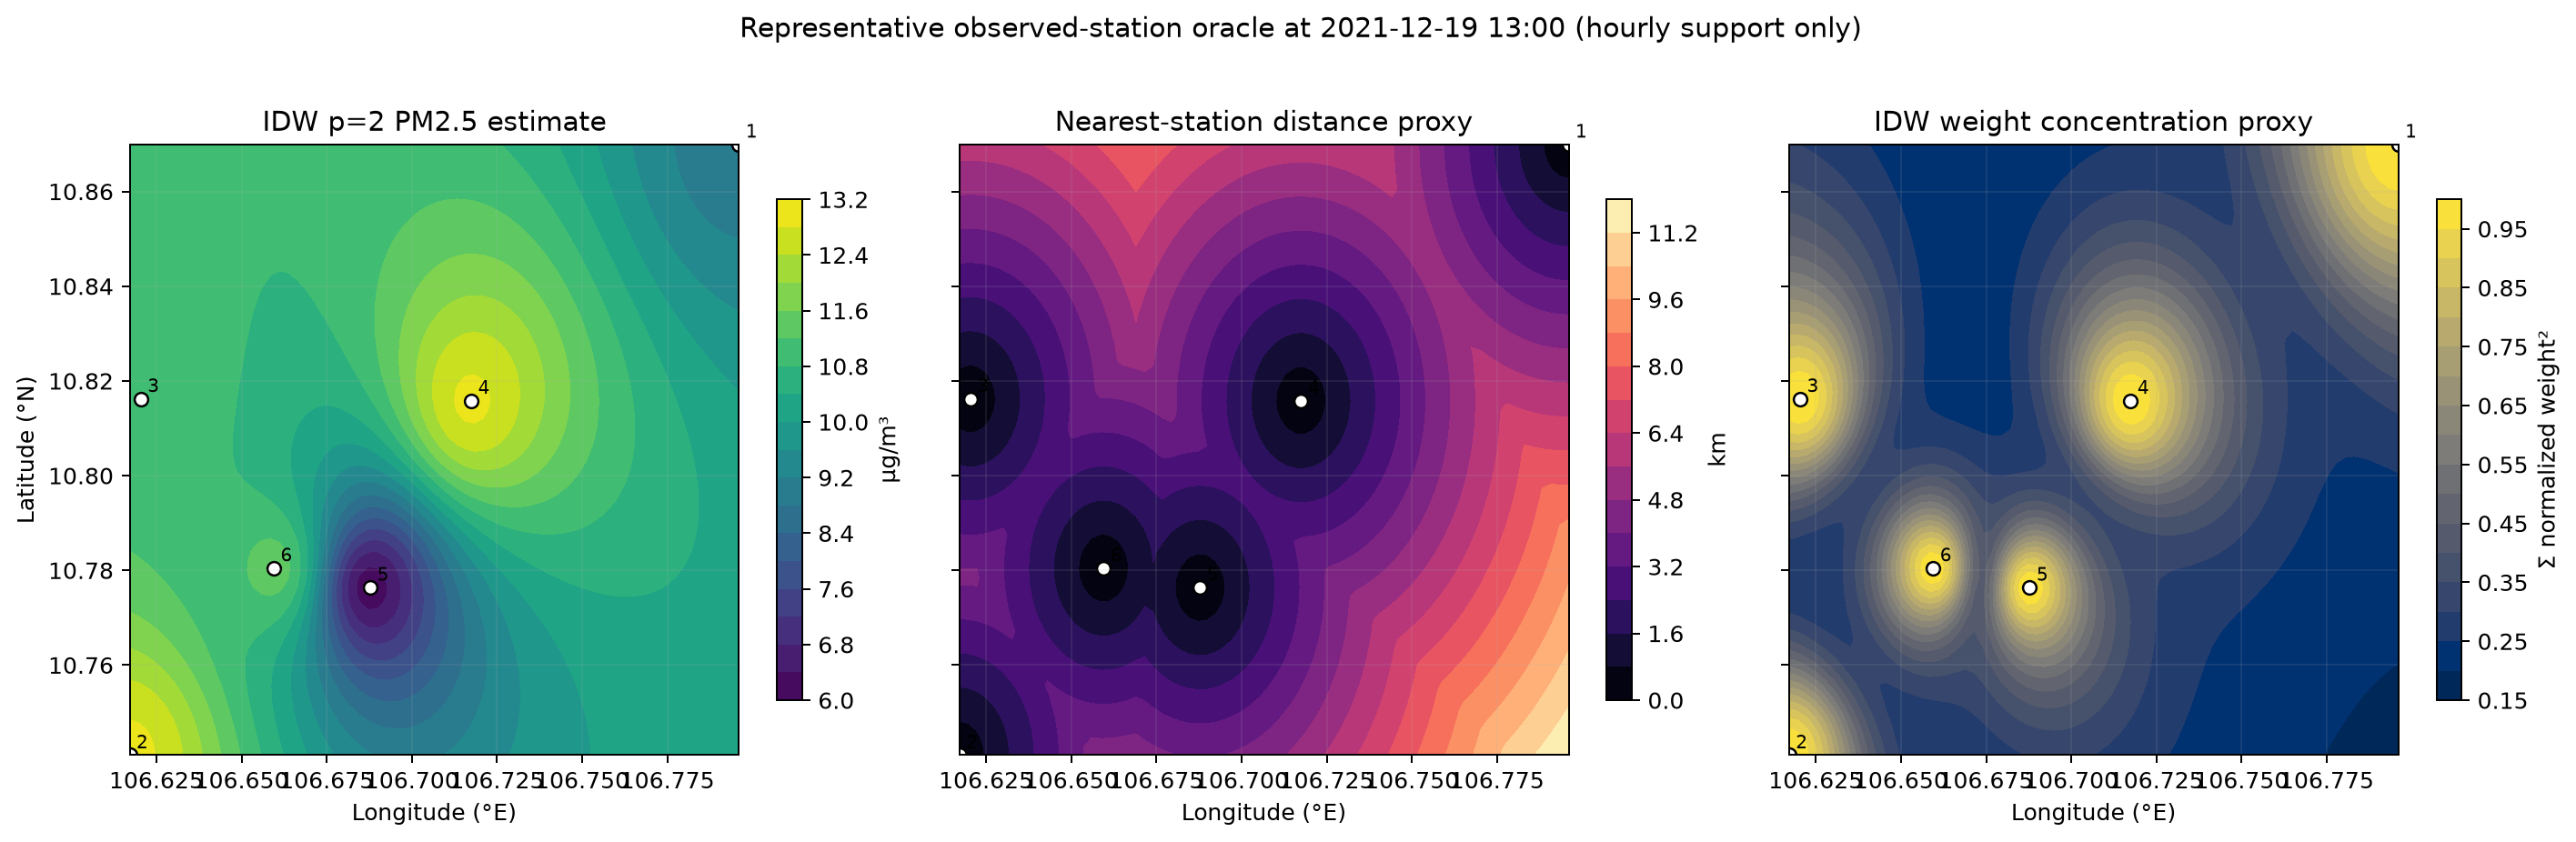

In [4]:
display(Image(filename=PROJECT_ROOT / "reports/figures/spatial_station_map.png"))
display(Image(filename=PROJECT_ROOT / "reports/figures/spatial_prediction_example.png"))

## Oracle versus deployment boundary

Both modes call the same spatial algorithm. Their only difference is the provenance of `station_values`:

- oracle values are actual observations at T and are used only to evaluate spatial interpolation;
- deployment values must be forecasts produced without observing T.

The spatial deployment wrapper has no dataset argument, so it cannot retrieve future observed PM2.5.

In [5]:
location_x = (10.79, 106.67)

# Use one existing validation timestamp with six saved t+1h V1 forecasts.
# The deployment mapping contains the `prediction` field only, never target_pm25.
forecast_rows = pd.read_csv(
    PROJECT_ROOT / "data/processed/xgboost_forecasting_predictions.csv",
    parse_dates=["target_time"],
    low_memory=False,
)
forecast_rows = forecast_rows.loc[
    forecast_rows["split"].eq("validation")
    & forecast_rows["model"].eq("xgboost_v1")
    & forecast_rows["horizon_hours"].eq(1)
]
complete_times = forecast_rows.groupby("target_time")["Station_No"].nunique()
target_time = complete_times.loc[complete_times.eq(6)].index[0]
selected_forecasts = forecast_rows.loc[forecast_rows["target_time"].eq(target_time)]
forecasted_values = dict(
    zip(selected_forecasts["Station_No"], selected_forecasts["prediction"])
)

clean = pd.read_csv(
    PROJECT_ROOT / "data/processed/airquality_hcmc_clean.csv",
    parse_dates=["date"],
)
observed_rows = clean.loc[clean["date"].eq(target_time)].dropna(subset=["PM2.5"])
observed_values = dict(zip(observed_rows["Station_No"], observed_rows["PM2.5"]))

oracle_estimate = estimate_oracle_pm25(
    *location_x, target_time, observed_values, method="idw", power=2
)
deployment_estimate = estimate_deployment_pm25(
    *location_x, target_time, forecasted_values, method="idw", power=2
)

pd.DataFrame(
    {
        "mode": ["spatial oracle (observed station values)", "deployment (saved station forecasts)"],
        "target_time": [target_time, target_time],
        "predicted_pm25": [oracle_estimate, deployment_estimate],
        "station_value_count": [len(observed_values), len(forecasted_values)],
    }
)

,mode,target_time,predicted_pm25,station_value_count
0,spatial oracle (observed station values),2022-01-31 09:00:00,16.208658,6
1,deployment (saved station forecasts),2022-01-31 09:00:00,18.389262,6
